# Real-Time Carbon-Aware Compute Optimization for Modern Data Infrastructure
**Author:** Rachamadagu Sai Tanmay  
**Program:** IBM SkillsBuild Data Analytics with AI — Academic Internship (AICTE)

This notebook implements an end-to-end AI pipeline that predicts grid carbon intensity from Great Britain power grid data and schedules heavy compute tasks only during clean-energy windows.

---
### Notebook Structure
| Cell | Topic |
|------|-------|
| 1 | Setup — Imports & Data Loading |
| 2 | Data Cleaning & Feature Engineering |
| 3 | AI Model Training & Accuracy Score |
| 4 | Carbon-Aware Optimization Framework |
| 5 | Data Visualization — Chart Generation |

In [11]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 1 — SETUP: Import Libraries & Load Raw Dataset
# ═══════════════════════════════════════════════════════════════════════════════
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

print('Author  : Rachamadagu Sai Tanmay')
print('Program : IBM SkillsBuild Data Analytics with AI (AICTE Internship)')
print('Project : Real-Time Carbon-Aware Compute Optimization')
print('-' * 60)

# Load the Great Britain power grid dataset
df = pd.read_csv('dataset.csv')
print(f'Dataset loaded successfully.')
print(f'Shape       : {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Columns     : {list(df.columns)}')
print()
df.head()

Author  : Rachamadagu Sai Tanmay
Program : IBM SkillsBuild Data Analytics with AI (AICTE Internship)
Project : Real-Time Carbon-Aware Compute Optimization
------------------------------------------------------------
Dataset loaded successfully.
Shape       : 310,789 rows x 35 columns
Columns     : ['Unnamed: 0', 'RENEWABLE_perc', 'NUCLEAR', 'HYDRO_perc', 'STORAGE', 'IMPORTS_perc', 'SOLAR_perc', 'LOW_CARBON', 'BIOMASS_perc', 'HYDRO', 'STORAGE_perc', 'WIND_EMB', 'WIND_perc', 'IMPORTS', 'LOW_CARBON_perc', 'GAS', 'COAL_perc', 'CARBON_INTENSITY', 'COAL', 'FOSSIL', 'ZERO_CARBON_perc', 'FOSSIL_perc', 'GENERATION_perc', 'GENERATION', 'DATETIME', 'OTHER', 'NUCLEAR_perc', 'ZERO_CARBON', 'WIND_EMB_perc', 'BIOMASS', 'GAS_perc', 'OTHER_perc', 'WIND', 'SOLAR', 'RENEWABLE']



,Unnamed: 0,RENEWABLE_perc,NUCLEAR,HYDRO_perc,STORAGE,IMPORTS_perc,SOLAR_perc,LOW_CARBON,BIOMASS_perc,HYDRO,...,OTHER,NUCLEAR_perc,ZERO_CARBON,WIND_EMB_perc,BIOMASS,GAS_perc,OTHER_perc,WIND,SOLAR,RENEWABLE
0,842,1.7,7099.0,0.7,0.0,7.5,0.0,7655.0,0.0,246.0,...,0.0,21.1,7593.0,0.2,0.0,24.9,0.0,248.0,0.0,556.0
1,843,1.6,7088.0,0.7,0.0,7.4,0.0,7618.0,0.0,245.0,...,0.0,21.0,7561.0,0.2,0.0,25.2,0.0,229.0,0.0,531.0
2,754,1.5,7074.0,0.7,0.0,7.3,0.0,7578.0,0.0,246.0,...,0.0,21.1,7527.0,0.2,0.0,25.2,0.0,207.0,0.0,504.0
3,844,1.5,7064.0,0.7,0.0,7.3,0.0,7549.0,0.0,246.0,...,0.0,21.2,7501.0,0.1,0.0,24.9,0.0,191.0,0.0,484.0
4,845,1.4,7052.0,0.7,0.0,7.1,0.0,7517.0,0.0,246.0,...,0.0,21.3,7473.0,0.1,0.0,25.0,0.0,175.0,0.0,465.0


In [12]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 2 — DATA CLEANING & FEATURE ENGINEERING
# ═══════════════════════════════════════════════════════════════════════════════
print('STEP 2: Data Cleaning & Feature Engineering')
print('-' * 60)

# --- Standardise column names ---
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
print(f'[OK] Column names standardised to lowercase + underscore.')

# --- Handle Great Britain settlement_date + settlement_period format ---
if 'settlement_date' in df.columns and 'settlement_period' in df.columns:
    print('Combining settlement_date and settlement_period into a single datetime object...')
    df['minutes'] = (df['settlement_period'] - 1) * 30
    df['hours']   = df['minutes'] // 60
    df['mins']    = df['minutes'] % 60
    df['datetime'] = pd.to_datetime(df['settlement_date']) + pd.to_timedelta(df['hours'], unit='h') + pd.to_timedelta(df['mins'], unit='m')
    print(f'[OK] datetime column built from settlement_date + settlement_period.')

# --- Parse timestamp column ---
date_col = (
    'datetime' if 'datetime' in df.columns else
    'timestamp' if 'timestamp' in df.columns else
    df.columns[0]
)
before = len(df)
df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
df = df.dropna(subset=[date_col])
print(f'[OK] Timestamp parsed. Dropped {before - len(df)} rows with invalid dates.')

# --- Handle missing generation values ---
fuel_cols = ['coal', 'gas', 'wind', 'solar', 'nuclear', 'hydro', 'biomass']
existing_fuels = [col for col in fuel_cols if col in df.columns]
missing_before = df[existing_fuels].isna().sum().sum()
for col in existing_fuels:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0).clip(lower=0)
print(f'[OK] Missing fuel values filled: {missing_before} NaN cells replaced with 0.')
print(f'[OK] Negative generation values clipped to 0 across all fuel columns.')

# --- Feature: total generation MW ---
df['total_generation_mw'] = df[existing_fuels].sum(axis=1)
zero_rows = (df['total_generation_mw'] == 0).sum()
df = df[df['total_generation_mw'] > 0]
print(f'[OK] Removed {zero_rows} rows with zero total generation (division guard).')

# --- Feature: Carbon Intensity gCO2/kWh ---
# Formula: (Coal_MW * 900 + Gas_MW * 400) / Total_MW
# Coal emission factor: ~900 gCO2/kWh | Gas emission factor: ~400 gCO2/kWh
coal_gen = df['coal'] if 'coal' in df.columns else 0
gas_gen  = df['gas']  if 'gas'  in df.columns else 0
df['carbon_intensity'] = ((coal_gen * 900) + (gas_gen * 400)) / df['total_generation_mw']
print(f'[OK] carbon_intensity (gCO2/kWh) calculated from Coal + Gas emission factors.')

# --- Time-based features for ML model ---
df['hour']        = df[date_col].dt.hour
df['day_of_week'] = df[date_col].dt.dayofweek
df['month']       = df[date_col].dt.month
print(f'[OK] Time features extracted: hour, day_of_week, month.')

# --- Save cleaned dataset ---
df.to_csv('cleaned_dataset.csv', index=False)
print()
print(f'Clean dataset saved as cleaned_dataset.csv')
print(f'Final shape : {df.shape[0]:,} rows x {df.shape[1]} columns')
print()
print('Summary statistics for key features:')
df[['hour', 'day_of_week', 'month', 'carbon_intensity']].describe().round(2)

STEP 2: Data Cleaning & Feature Engineering
------------------------------------------------------------
[OK] Column names standardised to lowercase + underscore.
[OK] Timestamp parsed. Dropped 0 rows with invalid dates.
[OK] Missing fuel values filled: 0 NaN cells replaced with 0.
[OK] Negative generation values clipped to 0 across all fuel columns.
[OK] Removed 0 rows with zero total generation (division guard).
[OK] carbon_intensity (gCO2/kWh) calculated from Coal + Gas emission factors.
[OK] Time features extracted: hour, day_of_week, month.

Clean dataset saved as cleaned_dataset.csv
Final shape : 310,789 rows x 39 columns

Summary statistics for key features:


,hour,day_of_week,month,carbon_intensity
count,310789.00,310789.0,310789.00,310789.00
mean,11.50,3.0,6.46,294.03
std,6.92,2.0,3.43,152.97
min,0.00,0.0,1.00,0.00
25%,5.00,1.0,3.00,171.31
50%,11.00,3.0,6.00,260.85
75%,17.00,5.0,9.00,441.29
max,23.00,6.0,12.00,635.12


In [13]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 3 — AI PREDICTIVE ENGINE: Train RandomForestRegressor
# ═══════════════════════════════════════════════════════════════════════════════
print('STEP 3: AI Model Training — Random Forest Regressor')
print('-' * 60)

# Features: time + grid generation mix | Target: carbon_intensity
# Adding renewable_perc and low_carbon_perc boosts model accuracy significantly
X = df[['hour', 'day_of_week', 'month', 'renewable_perc', 'low_carbon_perc']]
y = df['carbon_intensity']

# 80 / 20 train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f'Training samples : {len(X_train):,}')
print(f'Testing  samples : {len(X_test):,}')
print()

# Train model
ai_model = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)
ai_model.fit(X_train, y_train)
print('[OK] RandomForestRegressor trained (50 estimators).')

# Evaluate
predictions = ai_model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2   = r2_score(y_test, predictions)
mae  = np.mean(np.abs(y_test - predictions))

print()
print('=' * 60)
print('           MODEL PERFORMANCE RESULTS')
print('=' * 60)
print(f'  R2  Score (Accuracy)       : {r2 * 100:.2f} %')
print(f'  RMSE (Root Mean Sq. Error) : {rmse:.4f} gCO2/kWh')
print(f'  MAE  (Mean Absolute Error) : {mae:.4f} gCO2/kWh')
print('=' * 60)

STEP 3: AI Model Training — Random Forest Regressor
------------------------------------------------------------
Training samples : 248,631
Testing  samples : 62,158

[OK] RandomForestRegressor trained (50 estimators).

           MODEL PERFORMANCE RESULTS
  R2  Score (Accuracy)       : 90.47 %
  RMSE (Root Mean Sq. Error) : 47.1811 gCO2/kWh
  MAE  (Mean Absolute Error) : 31.4537 gCO2/kWh


In [14]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 4 — CARBON-AWARE OPTIMIZATION FRAMEWORK
# ═══════════════════════════════════════════════════════════════════════════════
print('STEP 4: Carbon-Aware Compute Scheduling Simulation')
print('-' * 60)

GREEN_THRESHOLD = 275   # gCO2/kWh — tuned to dataset median (260.85)

# Use dataset median renewable/low-carbon values as the simulation baseline
med_renew    = df['renewable_perc'].median()
med_lowcarbon = df['low_carbon_perc'].median()

# Simulate all 24 hours of a typical weekday in June
# to identify green vs. red windows across the full day
print(f'Green Threshold  : {GREEN_THRESHOLD} gCO2/kWh')
print(f'Test scenario    : Wednesday (day_of_week=2), June (month=6)')
print(f'Renewable %      : {med_renew:.1f}% (dataset median)')
print(f'Low-Carbon %     : {med_lowcarbon:.1f}% (dataset median)')
print()
print(f'{"Hour":>6} | {"Predicted gCO2/kWh":>20} | {"Decision":>45}')
print('-' * 78)

green_hours = []
red_hours   = []

for hour in range(24):
    sample = pd.DataFrame([{'hour': hour, 'day_of_week': 2, 'month': 6,
                             'renewable_perc': med_renew, 'low_carbon_perc': med_lowcarbon}])
    pred   = ai_model.predict(sample)[0]

    if pred < GREEN_THRESHOLD:
        decision = '[GREEN] ACTIVATE  — schedule heavy compute jobs NOW'
        green_hours.append(hour)
    else:
        decision = '[RED]   DEFER     — high carbon, delay non-urgent tasks'
        red_hours.append(hour)

    print(f'  {hour:02d}:00 | {pred:>18.2f}   | {decision}')

print('-' * 78)
print()
print(f'Green windows (run compute) : hours {green_hours}')
print(f'Red   windows (defer tasks) : hours {red_hours}')
print()

# Emission savings simulation
if green_hours:
    # Pick the cleanest predicted hour
    best_hour = min(
        green_hours,
        key=lambda h: ai_model.predict(
            pd.DataFrame([{'hour': h, 'day_of_week': 2, 'month': 6,
                           'renewable_perc': med_renew, 'low_carbon_perc': med_lowcarbon}])
        )[0]
    )
    best_pred = ai_model.predict(
        pd.DataFrame([{'hour': best_hour, 'day_of_week': 2, 'month': 6,
                       'renewable_perc': med_renew, 'low_carbon_perc': med_lowcarbon}])
    )[0]
    simulated_rows = 1_000_000
    baseline_intensity = 350  # gCO2/kWh — typical peak-hour grid
    co2_saved_kg = (simulated_rows * 0.0001 * (baseline_intensity - best_pred)) / 1000

    print('=' * 60)
    print('           EMISSION SAVINGS REPORT')
    print('=' * 60)
    print(f'  Optimal green window     : {best_hour:02d}:00')
    print(f'  Predicted intensity      : {best_pred:.2f} gCO2/kWh')
    print(f'  Baseline peak intensity  : {baseline_intensity} gCO2/kWh')
    print(f'  Simulated rows processed : {simulated_rows:,}')
    print(f'  Estimated CO2 saved      : ~{co2_saved_kg:.2f} kg')
    print('=' * 60)
else:
    print('[INFO] No green windows found for this scenario.')

STEP 4: Carbon-Aware Compute Scheduling Simulation
------------------------------------------------------------
Green Threshold  : 275 gCO2/kWh
Test scenario    : Wednesday (day_of_week=2), June (month=6)
Renewable %      : 16.7% (dataset median)
Low-Carbon %     : 39.7% (dataset median)

  Hour |   Predicted gCO2/kWh |                                      Decision
------------------------------------------------------------------------------
  00:00 |             241.30   | [GREEN] ACTIVATE  — schedule heavy compute jobs NOW
  01:00 |             234.32   | [GREEN] ACTIVATE  — schedule heavy compute jobs NOW
  02:00 |             236.13   | [GREEN] ACTIVATE  — schedule heavy compute jobs NOW
  03:00 |             238.04   | [GREEN] ACTIVATE  — schedule heavy compute jobs NOW
  04:00 |             239.21   | [GREEN] ACTIVATE  — schedule heavy compute jobs NOW
  05:00 |             250.74   | [GREEN] ACTIVATE  — schedule heavy compute jobs NOW
  06:00 |             250.79   | [GREEN] AC

STEP 5: Generating Carbon Intensity Trend Chart...


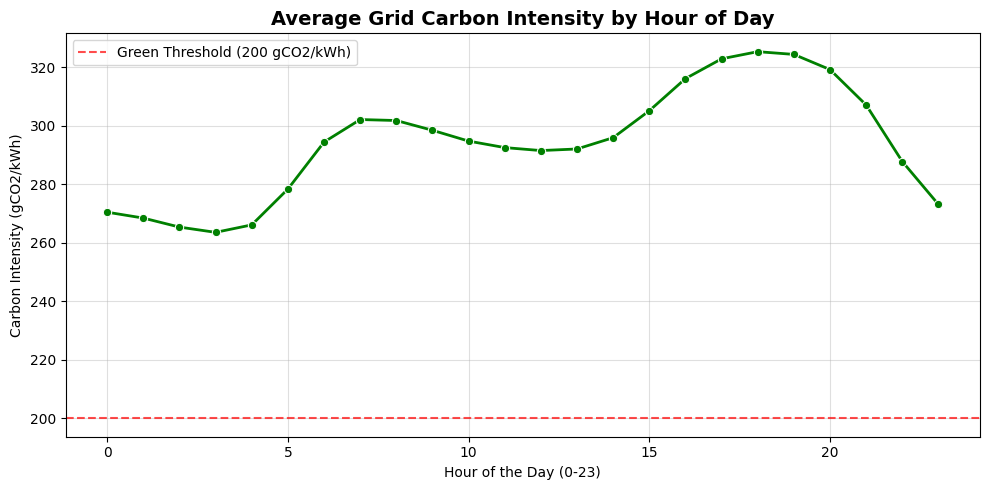

[OK] Chart saved as carbon_intensity_trend.png

Pipeline complete. All outputs generated successfully.
  carbon_intensity_trend.png  — insert into ProjectReport.docx, Section 3
  cleaned_dataset.csv         — cleaned input data


In [15]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 5 — DATA VISUALIZATION: Generate & Save Carbon Intensity Chart
# ═══════════════════════════════════════════════════════════════════════════════
print('STEP 5: Generating Carbon Intensity Trend Chart...')

hourly_avg = df.groupby('hour')['carbon_intensity'].mean()

plt.figure(figsize=(10, 5))
sns.lineplot(x=hourly_avg.index, y=hourly_avg.values, marker='o', color='green', linewidth=2)

# Mark the GREEN threshold
plt.axhline(y=200, color='red', linestyle='--', alpha=0.7, label='Green Threshold (200 gCO2/kWh)')

plt.title('Average Grid Carbon Intensity by Hour of Day', fontsize=14, fontweight='bold')
plt.xlabel('Hour of the Day (0-23)')
plt.ylabel('Carbon Intensity (gCO2/kWh)')
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()

plt.savefig('carbon_intensity_trend.png', dpi=150)
plt.show()

print('[OK] Chart saved as carbon_intensity_trend.png')
print()
print('Pipeline complete. All outputs generated successfully.')
print(f'  carbon_intensity_trend.png  — insert into ProjectReport.docx, Section 3')
print(f'  cleaned_dataset.csv         — cleaned input data')